In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
from cartopy import crs as ccrs # Cartography library
import geopy.distance
import re
import pandas as pd
import cartopy.feature as cfeature
import matplotlib.patches as patches
import yaml
from scipy.spatial.distance import cdist

In [2]:
### Link of the data
root = "ipfs://QmTSoNnvXX9bzu5SgVHeP7hVCuqJKFAkjk21LvzzCSGz9p"

In [3]:
def find_closest_grid_point(target_lon, target_lat, lon_array, lat_array,n_closest=4):
    """
    Find the closest grid point in the dataset to the given lon/lat.
    """
    targets_coords = np.radians([target_lat, target_lon])
    coords = np.column_stack([np.radians(lat_array), np.radians(lon_array)])

    ### calculate haversine distances

    def haversine_distance(coord1, coord2):
        lat1, lon1 = coord1
        lat2, lon2 = coord2
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        radius_earth = 6371  # Earth radius in kilometers
        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        return 2 * np.arcsin(np.sqrt(a)) * radius_earth

    #return targets_coords, coords
    distances = cdist([targets_coords], coords, metric=haversine_distance)[0]
    #closest_indices = np.argsort(distances)[:n_closest]
    closest_indices = np.concat(np.argwhere(distances < 1))  # Only consider points within 1 km
    return closest_indices, distances[closest_indices]

def cal_uv_wind(ds):
    u = -ds.wspd*np.sin(np.deg2rad(ds.wdir))
    v = -ds.wspd*np.cos(np.deg2rad(ds.wdir))
    return u,v

In [4]:
def create_dataset(adcp_u, adcp_v, xband_u, xband_v, uwind, vwind, heading, dist, lon, time):
    """
    Create an xarray Dataset from the matched ADCP and X-band data.
    """
    ds = xr.Dataset(
        {
            'adcp_u': (('time'), adcp_u),
            'adcp_v': (('time'), adcp_v),
            'xband_u': (('time'), xband_u),
            'xband_v': (('time'), xband_v),
            'uwind': (('time'), uwind),
            'vwind': (('time'), vwind),
            'heading': (('time'), heading),
            'dist': (('time'), dist),
            'lon': (('time'), lon),
        },
        coords={
            'time': time
        }
    )
    return ds

In [5]:
def match_adcp_xband_ctd(xband, adcp, ctd_stations, dship, depth=17):
    """
    Match ADCP and X-band data based on CTD stations.
    """
    adcp_u_list = []
    adcp_v_list = []
    xband_u_list = []
    xband_v_list = []
    heading_list = []
    dist_list = []
    lon_list = []
    time_list = []
    uwind_list = []
    vwind_list = []

    for id in ctd_stations.index:
        time_slice = [stations_adcp.iloc[id]['start'], stations_adcp.iloc[id]['end']]
        ds_xband_cut = xband.where((xband.time >= np.datetime64(time_slice[0])) \
                                    & (xband.time <= np.datetime64(time_slice[1])), drop=True)
        times_xband_cut = np.unique(ds_xband_cut.time)
        for times_id in times_xband_cut:
            ds_xband_temp = ds_xband_cut.where(ds_xband_cut.time == times_id, drop=True)
            nearest_adcp = adcp.sel(time=times_id, method='nearest',tolerance='10min')
            nearest_dship = dship.sel(time=times_id, method='nearest',tolerance='10min')
            if ds_xband_temp.time.size > 12 and nearest_adcp.time.size > 0:
                points, dist = find_closest_grid_point(
                    target_lon = nearest_adcp.LONGITUDE.values,
                    target_lat = nearest_adcp.LATITUDE.values,
                    lon_array = ds_xband_temp.longitude.values,
                    lat_array = ds_xband_temp.latitude.values,
                    n_closest=12)
                u_temp,v_temp = cal_uv_wind(nearest_dship)
                adcp_u_list.append(nearest_adcp.sel(DEPTH=depth).U.values)
                adcp_v_list.append(nearest_adcp.sel(DEPTH=depth).V.values)
                heading_list.append(nearest_dship.ship_heading.values)
                xband_u_list.append(ds_xband_temp.isel(measurement=points).eastward_sea_water_velocity.mean().values)
                xband_v_list.append(ds_xband_temp.isel(measurement=points).northward_sea_water_velocity.mean().values)
                uwind_list.append(u_temp)
                vwind_list.append(v_temp)
                dist_list.append(dist.mean())
                lon_list.append(nearest_dship.lon.values)
                time_list.append(nearest_dship.time.values)
    return create_dataset(np.array(adcp_u_list), 
                          np.array(adcp_v_list), 
                          np.array(xband_u_list), 
                          np.array(xband_v_list), 
                          np.array(uwind_list),
                          np.array(vwind_list),
                          np.array(heading_list), 
                          np.array(dist_list), 
                          np.array(lon_list), 
                          np.array(time_list))


In [6]:
def match_adcp_xband_movement(xband, adcp, dship, time_slice, depth=17, ship_speed_threshold=4.5):
    """
    Match ADCP and X-band data based on ship movement.
    """
    adcp_u_list = []
    adcp_v_list = []
    xband_u_list = []
    xband_v_list = []
    heading_list = []
    dist_list = []
    lon_list = []
    time_list = []
    uwind_list = []
    vwind_list = []

    ds_dship_stage = dship.sel(time=slice(time_slice[0], time_slice[1]))
    ds_adcp_stage = adcp.sel(time=slice(time_slice[0], time_slice[1]),DEPTH=depth)
    xband_radar_stage = xband.where(
        (xband.time>= np.datetime64(time_slice[0])) & \
         (xband.time<= np.datetime64(time_slice[1])),drop=True)
    
    times_xband_stage = np.unique(xband_radar_stage.time)
    ### find nearest time in adcp and xband
    for times_id in times_xband_stage:
        nearest_adcp = ds_adcp_stage.sel(time=times_id, method='nearest',tolerance='10min')
        nearest_dship = ds_dship_stage.sel(time=times_id, method='nearest',tolerance='10min')
        ds_xband_temp = xband_radar_stage.where(xband_radar_stage.time == times_id, drop=True)

        ### only consider when ship speed is above threshold
        if (nearest_dship.ship_speed.values >= ship_speed_threshold) and \
           (ds_xband_temp.time.size > 96) and (nearest_adcp.time.size > 0):
            points,dist = find_closest_grid_point(
                target_lon = nearest_adcp.LONGITUDE.values,
                target_lat = nearest_adcp.LATITUDE.values,
                lon_array = ds_xband_temp.longitude.values,
                lat_array = ds_xband_temp.latitude.values,
                n_closest=12)
            u_temp,v_temp = cal_uv_wind(nearest_dship)
            adcp_u_list.append(nearest_adcp.U.values)
            adcp_v_list.append(nearest_adcp.V.values)
            xband_u_list.append(ds_xband_temp.isel(measurement=points).eastward_sea_water_velocity.mean().values)
            xband_v_list.append(ds_xband_temp.isel(measurement=points).northward_sea_water_velocity.mean().values)
            uwind_list.append(u_temp)
            vwind_list.append(v_temp)
            heading_list.append(nearest_dship.ship_heading.values)
            dist_list.append(dist.mean())
            lon_list.append(nearest_dship.lon.values)
            time_list.append(nearest_dship.time.values)
    return create_dataset(np.array(adcp_u_list), 
                          np.array(adcp_v_list), 
                          np.array(xband_u_list), 
                          np.array(xband_v_list),
                          np.array(uwind_list),
                          np.array(vwind_list),
                          np.array(heading_list), 
                          np.array(dist_list), 
                          np.array(lon_list), 
                          np.array(time_list))

In [7]:
def calculate_velocity_magnitude(u, v):
    """
    Calculate the velocity magnitude from u and v components.
    """
    return np.sqrt(u**2 + v**2)

def calculate_direction(u, v):
    """
    Calculate the direction of the current from u and v components.
    """
    return (np.rad2deg(np.arctan2(u, v)) + 360) % 360

def calculate_current_mag_dir(u, v):
    """
    Calculate the current magnitude and direction from u and v components.
    """
    magnitude = calculate_velocity_magnitude(u, v)
    direction = calculate_direction(u, v)
    return magnitude, direction

def calculate_current_cross_along(adcp_u, adcp_v, xband_u, xband_v, angle):
    """
    Calculate the current cross-along values.
    """
    # Calculate the cross-along current
    cross_adcp = (adcp_u) * np.cos(np.radians(angle)) - (adcp_v) * np.sin(np.radians(angle))
    cross_xband = (xband_u) * np.cos(np.radians(angle)) - (xband_v) * np.sin(np.radians(angle))
    long_adcp = (adcp_u) * np.sin(np.radians(angle)) + (adcp_v) * np.cos(np.radians(angle))
    long_xband = (xband_u) * np.sin(np.radians(angle)) + (xband_v) * np.cos(np.radians(angle))
    return cross_adcp, cross_xband, long_adcp, long_xband

In [8]:
### Calling radiosondes from METEOR
ds_adcp_75= xr.open_dataset(
    f"{root}/ADCP/met_203_vmadcp_75khz.zarr",engine="zarr").rename({"TIME":"time"})

ds_xband_radar= xr.open_dataset(
    f"{root}/Radar_Derived_Currents_M203.zarr",engine="zarr")

ds_dship= xr.open_dataset(
    f"{root}/DShip.zarr",engine="zarr")


In [9]:
with open("/Users/hans/Documents/bow_tie/actionlog_book/stations_bowtie_ctd.yaml", 'r') as stream:
    dic_ctd = yaml.safe_load(stream)
stations = pd.DataFrame(dic_ctd['stations'])

In [10]:
stations_adcp = stations[stations['start']>=ds_adcp_75.time[0].values].reset_index(drop=True)

In [11]:
ds_ctd_matched = match_adcp_xband_ctd(ds_xband_radar, ds_adcp_75, stations_adcp, ds_dship)
local_offset_ctd = np.floor_divide(ds_ctd_matched.lon.values, 15)
hours_ctd = (ds_ctd_matched.time['time.hour'] + local_offset_ctd) % 24

In [12]:
ds_stage_1 = match_adcp_xband_movement(
    ds_xband_radar, ds_adcp_75, ds_dship, ('2024-08-28', '2024-09-04'), 17, 1
)
local_offset_stage_1 = np.floor_divide(ds_stage_1.lon.values, 15)
hours_stage_1 = (ds_stage_1.time['time.hour'] + local_offset_stage_1) % 24

In [13]:
ds_stage_2 = match_adcp_xband_movement(
    ds_xband_radar, ds_adcp_75, ds_dship, ('2024-09-15', '2024-09-24'), 17, 1)
local_offset_stage_2 = np.floor_divide(ds_stage_2.lon.values, 15)
hours_stage_2 = (ds_stage_2.time['time.hour'] + local_offset_stage_2) % 24

In [14]:
vel_adcp_ctd, dir_adcp_ctd = calculate_current_mag_dir(ds_ctd_matched.adcp_u, ds_ctd_matched.adcp_v)
vel_xband_ctd, dir_xband_ctd = calculate_current_mag_dir(ds_ctd_matched.xband_u, ds_ctd_matched.xband_v)
vel_adcp_stage1, dir_adcp_stage1 = calculate_current_mag_dir(ds_stage_1.adcp_u, ds_stage_1.adcp_v)
vel_xband_stage1, dir_xband_stage1 = calculate_current_mag_dir(ds_stage_1.xband_u, ds_stage_1.xband_v)
vel_wind_stage1, dir_wind_stage1 = calculate_current_mag_dir(ds_stage_1.uwind, ds_stage_1.vwind)
vel_adcp_stage2, dir_adcp_stage2 = calculate_current_mag_dir(ds_stage_2.adcp_u, ds_stage_2.adcp_v)
vel_xband_stage2, dir_xband_stage2 = calculate_current_mag_dir(ds_stage_2.xband_u, ds_stage_2.xband_v)
vel_wind_stage2, dir_wind_stage2 = calculate_current_mag_dir(ds_stage_2.uwind, ds_stage_2.vwind)

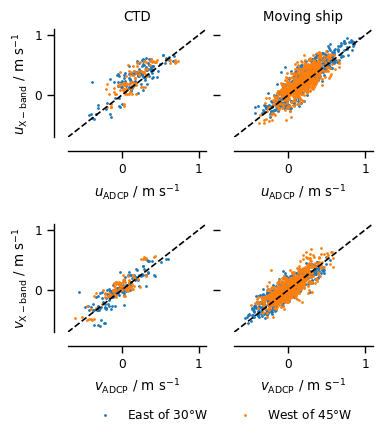

In [15]:
sns.set_context("paper")
fig = plt.figure(figsize=(10/2.54,10/2.54))
ax1 = fig.add_subplot(221)
ax1.plot(ds_ctd_matched.adcp_u.where(ds_ctd_matched.lon>-30), 
         ds_ctd_matched.xband_u.where(ds_ctd_matched.lon>-30), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot(ds_ctd_matched.adcp_u.where(ds_ctd_matched.lon<-45), 
         ds_ctd_matched.xband_u.where(ds_ctd_matched.lon<-45), 'o',
         markersize=1, label=r'Western of 45$\degree$W')
ax1.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax1.set_xlim([-0.7,1.1])
ax1.set_ylim([-0.7,1.1])
ax1.set_yticks([0,1])
sns.despine(offset=10,ax=ax1)
ax1.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax1.set_title('CTD')

ax2 = fig.add_subplot(222)
ax2.plot(ds_stage_1.adcp_u.where(ds_stage_1.lon>-30), 
         ds_stage_1.xband_u.where(ds_stage_1.lon>-30), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax2.plot(ds_stage_2.adcp_u.where(ds_stage_2.lon<-45), 
         ds_stage_2.xband_u.where(ds_stage_2.lon<-45), 'o',
         markersize=1, label=r'Western of 45$\degree$W')
ax2.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax2.set_xlim([-0.7,1.1])
ax2.set_ylim([-0.7,1.1])
ax2.set_yticks([0,1])
ax2.set_yticklabels({})
sns.despine(offset=10,ax=ax2)
ax2.spines['left'].set_visible(False)
ax2.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax2.set_title('Moving ship')

ax3 = fig.add_subplot(223)
ax3.plot(ds_ctd_matched.adcp_v.where(ds_ctd_matched.lon>-30), 
         ds_ctd_matched.xband_v.where(ds_ctd_matched.lon>-30), 'o',
         markersize=1, label=r'East of 30$\degree$W')
ax3.plot(ds_ctd_matched.adcp_v.where(ds_ctd_matched.lon<-45), 
         ds_ctd_matched.xband_v.where(ds_ctd_matched.lon<-45), 'o',
         markersize=1, label=r'West of 45$\degree$W')
ax3.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax3.set_xlim([-0.7,1.1])
ax3.set_ylim([-0.7,1.1])
ax3.set_yticks([0,1])
sns.despine(offset=10,ax=ax3)
ax3.set_ylabel(r'$v_{\mathrm{X-band}}$ / m s$^{-1}$')
ax3.set_xlabel(r'$v_{\mathrm{ADCP}}$ / m s$^{-1}$')

ax4 = fig.add_subplot(224)
ax4.plot(ds_stage_1.adcp_v.where(ds_stage_1.lon>-30), 
         ds_stage_1.xband_v.where(ds_stage_1.lon>-30), 'o',
         markersize=1, label=r'East of 30$\degree$W')
ax4.plot(ds_stage_2.adcp_v.where(ds_stage_2.lon<-45), 
         ds_stage_2.xband_v.where(ds_stage_2.lon<-45), 'o',
         markersize=1, label=r'West of 45$\degree$W')
ax4.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax4.set_xlim([-0.7,1.1])
ax4.set_ylim([-0.7,1.1])
ax4.set_yticks([0,1])
ax4.set_yticklabels({})
sns.despine(offset=10,ax=ax4)
ax4.spines['left'].set_visible(False)
ax4.set_xlabel(r'$v_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax4.legend(loc='upper left', bbox_to_anchor=(-1.1,-0.6), ncol=2, frameon=False)

plt.subplots_adjust(hspace=0.8)
plt.savefig('../figures/zonal_meridional_current_adcp_xband.png',
            format='png',dpi=300,bbox_inches='tight',orientation={'landscape'})


Text(0.5, 1.0, 'CTD')

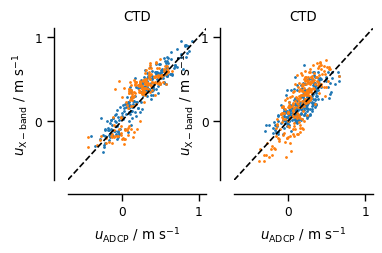

In [16]:
sns.set_context("paper")
fig = plt.figure(figsize=(10/2.54,5/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(ds_stage_1.adcp_u.where((hours_stage_1<=6) | (hours_stage_1>=22)), 
         ds_stage_1.xband_u.where((hours_stage_1<=6) | (hours_stage_1>=22)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot(ds_stage_1.adcp_u.where((hours_stage_1>=12) & (hours_stage_1<=19)), 
         ds_stage_1.xband_u.where((hours_stage_1>=12) & (hours_stage_1<=19)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax1.set_xlim([-0.7,1.1])
ax1.set_ylim([-0.7,1.1])
ax1.set_yticks([0,1])
sns.despine(offset=10,ax=ax1)
ax1.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax1.set_title('CTD')

ax1 = fig.add_subplot(122)
ax1.plot(ds_stage_2.adcp_u.where((hours_stage_2<=6) | (hours_stage_2>=22)), 
         ds_stage_2.xband_u.where((hours_stage_2<=6) | (hours_stage_2>=22)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot(ds_stage_2.adcp_u.where((hours_stage_2>=12) & (hours_stage_2<=19)), 
         ds_stage_2.xband_u.where((hours_stage_2>=12) & (hours_stage_2<=19)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax1.set_xlim([-0.7,1.1])
ax1.set_ylim([-0.7,1.1])
ax1.set_yticks([0,1])
sns.despine(offset=10,ax=ax1)
ax1.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax1.set_title('CTD')


In [17]:
hourly_stage_1 = ds_stage_1.groupby(hours_stage_1).mean()
hourly_stage_2 = ds_stage_2.groupby(hours_stage_2).mean()

In [81]:
hourly_ctd_west = ds_ctd_matched.where(ds_ctd_matched.lon<-45).groupby(hours_ctd).quantile(0.5)
hourly_ctd_east = ds_ctd_matched.where(ds_ctd_matched.lon>-30).groupby(hours_ctd).quantile(0.5)

In [31]:
radians_hours = np.radians(np.arange(24)/24*360)

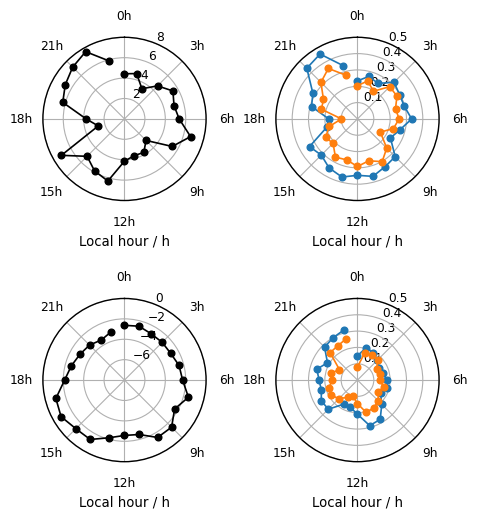

In [68]:
sns.set_context("paper")
fig = plt.figure(figsize=(14/2.54,14/2.54))
ax1 = fig.add_subplot(221,polar=True)
plt.plot(radians_hours, hourly_stage_1.uwind, 'o-k', label='Stage 2')
ax1.set_theta_direction(-1)
ax1.set_theta_offset(np.pi/2.0)
ax1.set_ylim([0,8])
ax1.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax1.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax1.set_xlabel('Local hour / h')

ax2 = fig.add_subplot(222,polar=True)
plt.plot(radians_hours, hourly_stage_1.xband_u, 'o-', label='Stage 2')
plt.plot(radians_hours, hourly_stage_1.adcp_u, 'o-', label='Stage 2')
ax2.set_theta_direction(-1)
ax2.set_theta_offset(np.pi/2.0)
ax2.set_ylim([0,0.5])
ax2.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax2.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax2.set_xlabel('Local hour / h')

ax3 = fig.add_subplot(223,polar=True)
plt.plot(radians_hours, hourly_stage_2.uwind, 'o-k', label='Stage 2')
ax3.set_theta_direction(-1)
ax3.set_theta_offset(np.pi/2.0)
ax3.set_ylim([-8,0])
ax3.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax3.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax3.set_xlabel('Local hour / h')

ax4 = fig.add_subplot(224,polar=True)
plt.plot(radians_hours, hourly_stage_2.xband_u, 'o-', label='Stage 2')
plt.plot(radians_hours, hourly_stage_2.adcp_u, 'o-', label='Stage 2')
ax4.set_theta_direction(-1)
ax4.set_theta_offset(np.pi/2.0)
ax4.set_ylim([0,0.5])
ax4.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax4.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax4.set_xlabel('Local hour / h')

plt.subplots_adjust(hspace=0.6)

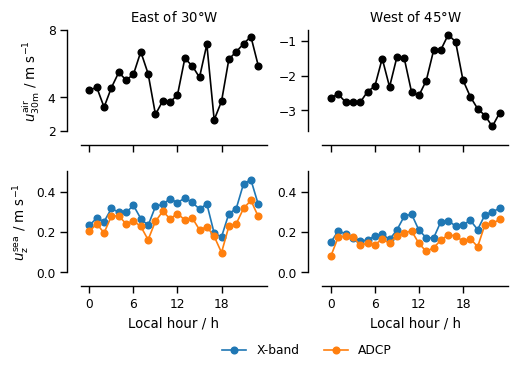

In [100]:
sns.set_context("paper")
fig = plt.figure(figsize=(14/2.54,8/2.54))
ax1 = fig.add_subplot(221)
l1 = plt.plot(np.arange(0,24,1), hourly_stage_1.uwind, 'o-k', label=r'u_\mathrm{30m}')
ax1.set_ylim([2,8])
ax1.set_yticks([2,4,8])
ax1.set_xticks(np.arange(0,24,6))
sns.despine(offset=10,ax=ax1)
ax1.set_xticklabels([])
ax1.set_title(r'East of 30$\degree$W')
ax1.set_ylabel(r'$u^\mathrm{air}_{\mathrm{30m}}$ / m s$^{-1}$')

ax2 = fig.add_subplot(222)
plt.plot(np.arange(0,24,1), hourly_stage_2.uwind, 'o-k')
ax2.set_xticks(np.arange(0,24,6))
ax2.set_yticks([-3,-2,-1])
sns.despine(offset=10,ax=ax2)
ax2.set_title(r'West of 45$\degree$W')
ax2.set_xticklabels([])

ax3 = fig.add_subplot(223)
plt.plot(np.arange(0,24,1), hourly_stage_1.xband_u, 'o-' )
plt.plot(np.arange(0,24,1), hourly_stage_1.adcp_u, 'o-')
ax3.set_ylim([0,0.5])
ax3.set_xticks(np.arange(0,24,6))
ax3.set_xlabel('Local hour / h')
sns.despine(offset=10,ax=ax3)
ax3.set_ylabel(r'$u^\mathrm{sea}_{\mathrm{z}}$ / m s$^{-1}$')

ax4 = fig.add_subplot(224)
plt.plot(np.arange(0,24,1), hourly_stage_2.xband_u, 'o-', label='X-band')
plt.plot(np.arange(0,24,1), hourly_stage_2.adcp_u, 'o-', label='ADCP')
ax4.set_ylim([0,0.5])
ax4.set_xticks(np.arange(0,24,6))
ax4.set_xlabel('Local hour / h')
sns.despine(offset=10,ax=ax4)
ax4.legend(loc='upper left', bbox_to_anchor=(-0.6,-0.6), ncol=2, frameon=False)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig('../figures/diurnal_cycle_u_component.png',
            format='png',dpi=300,bbox_inches='tight',orientation={'landscape'})

Text(0.5, 0, 'Local hour / h')

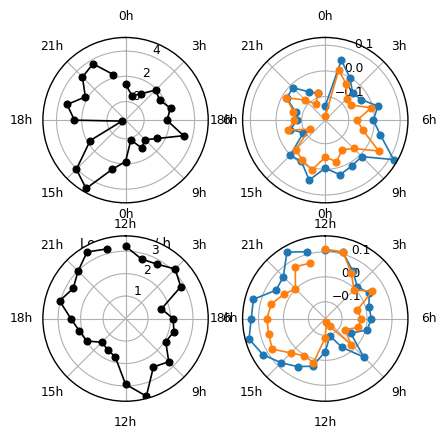

In [58]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,12/2.54))
ax1 = fig.add_subplot(221,polar=True)
plt.plot(radians_hours, hourly_stage_1.vwind, 'o-k', label='Stage 2')
ax1.set_theta_direction(-1)
ax1.set_theta_offset(np.pi/2.0)
ax1.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax1.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax1.set_xlabel('Local hour / h')

ax2 = fig.add_subplot(222,polar=True)
plt.plot(radians_hours, hourly_stage_1.xband_v, 'o-', label='Stage 2')
plt.plot(radians_hours, hourly_stage_1.adcp_v, 'o-', label='Stage 2')
ax2.set_theta_direction(-1)
ax2.set_theta_offset(np.pi/2.0)
ax2.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax2.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax1.set_xlabel('Local hour / h')

ax3 = fig.add_subplot(223,polar=True)
plt.plot(radians_hours, hourly_stage_2.vwind, 'o-k', label='Stage 2')
ax3.set_theta_direction(-1)
ax3.set_theta_offset(np.pi/2.0)
ax3.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax3.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax1.set_xlabel('Local hour / h')

ax4 = fig.add_subplot(224,polar=True)
plt.plot(radians_hours, hourly_stage_2.xband_v, 'o-', label='Stage 2')
plt.plot(radians_hours, hourly_stage_2.adcp_v, 'o-', label='Stage 2')
ax4.set_theta_direction(-1)
ax4.set_theta_offset(np.pi/2.0)
ax4.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax4.set_xticklabels(['0h','3h','6h','9h','12h','15h','18h','21h']); ax1.set_xlabel('Local hour / h')

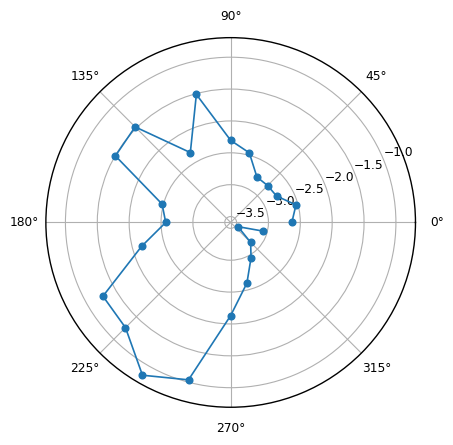

In [39]:
plt.polar(radians_hours, hourly_stage_2.uwind, 'o-', label='Stage 2')

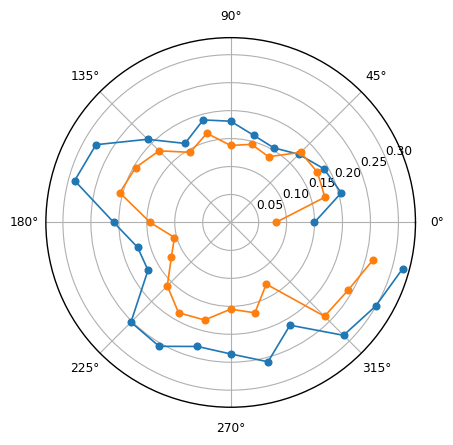

In [33]:
plt.polar(radians_hours, hourly_stage_2.xband_u, 'o-', label='Stage 1')
plt.polar(radians_hours, hourly_stage_2.adcp_u, 'o-', label='Stage 1')

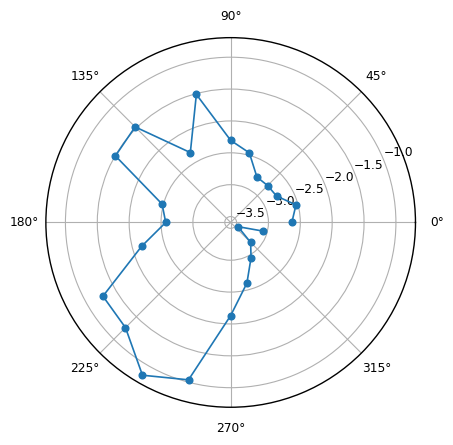

In [104]:
plt.polar(radians_hours, hourly_stage_2.uwind, 'o-', label='Stage 1')

In [ ]:
plt.polar(, hourly_stage_2.uwind, 'o-', label='Stage 1')

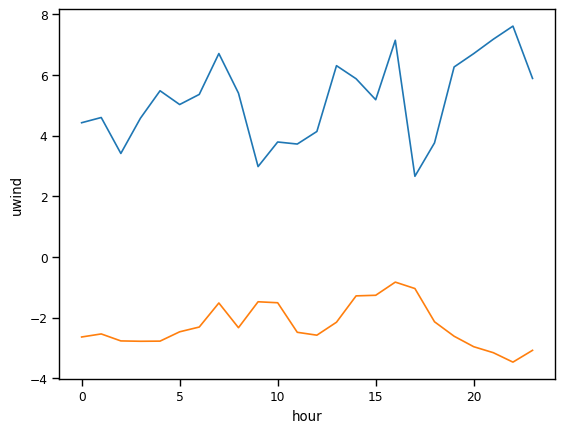

In [92]:
hourly_stage_1.uwind.plot()
hourly_stage_2.uwind.plot()

In [29]:
hourly_stage_2.uwind.mean()

<xarray.DataArray 'uwind' ()> Size: 8B
array(-2.25098448)

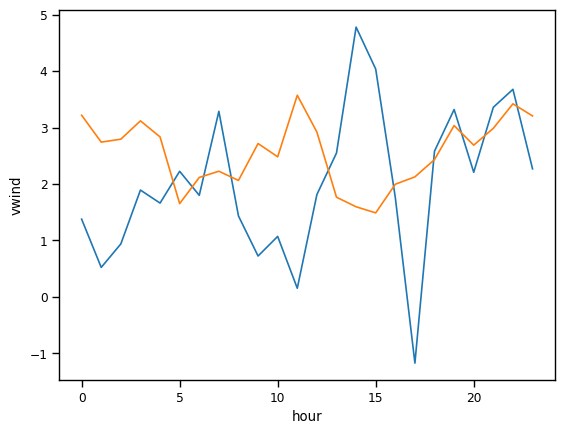

In [19]:
hourly_stage_1.vwind.plot()
hourly_stage_2.vwind.plot()

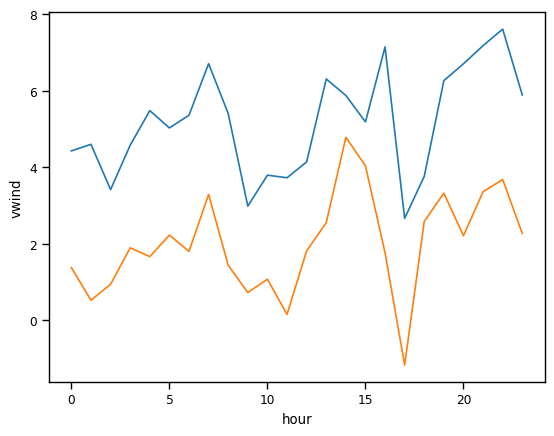

In [24]:
hourly_stage_1.uwind.plot()
hourly_stage_1.vwind.plot()

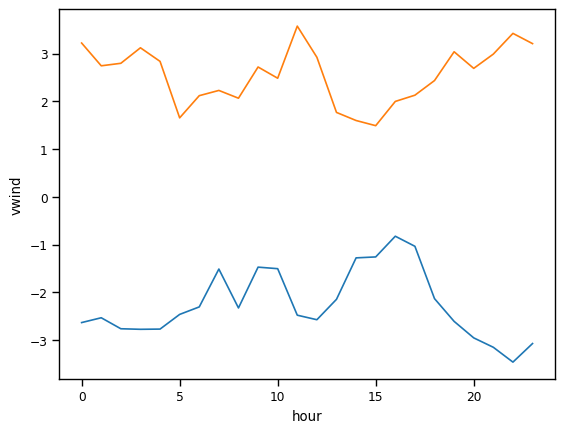

In [20]:
hourly_stage_2.uwind.plot()
hourly_stage_2.vwind.plot()

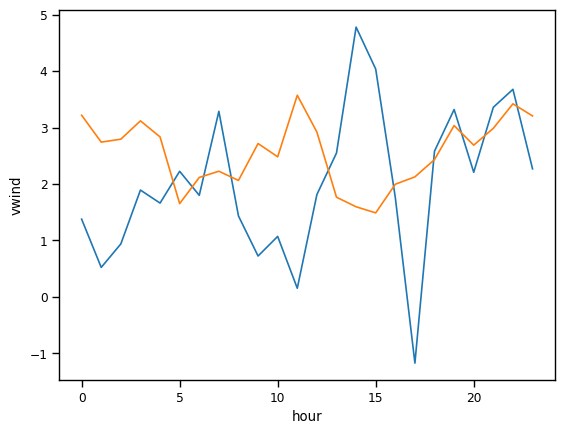

In [18]:
hourly_stage_1.vwind.plot()
hourly_stage_2.vwind.plot()

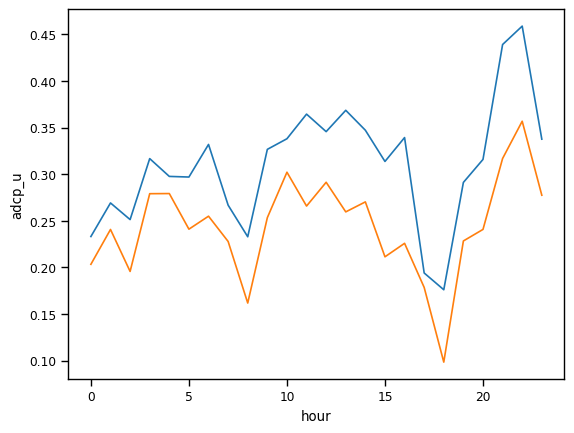

In [ ]:
hourly_stage_1.xband_u.plot()
hourly_stage_1.adcp_u.plot()

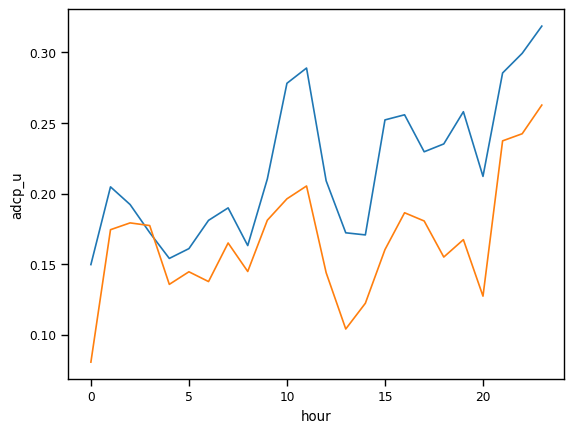

In [25]:
hourly_stage_2.xband_u.plot()
hourly_stage_2.adcp_u.plot()

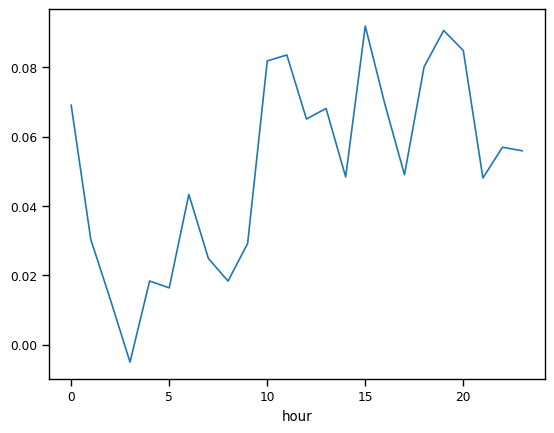

In [26]:
(hourly_stage_2.xband_u - hourly_stage_2.adcp_u).plot()


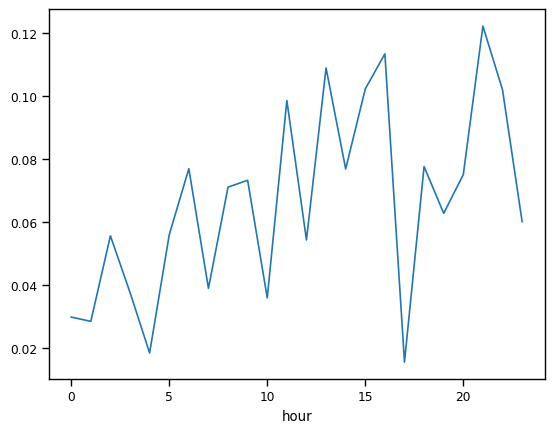

In [27]:
(hourly_stage_1.xband_u - hourly_stage_1.adcp_u).plot()

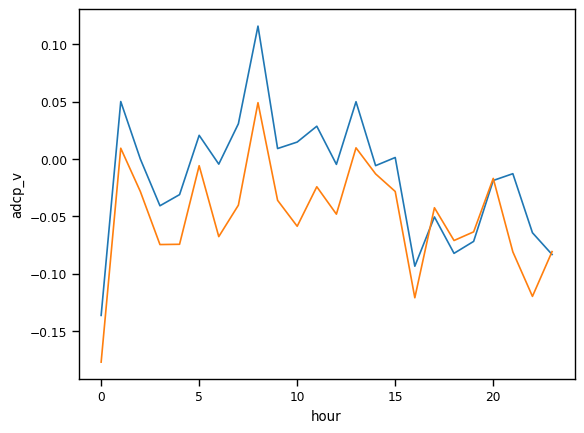

In [22]:
hourly_stage_1.xband_v.plot()
hourly_stage_1.adcp_v.plot()

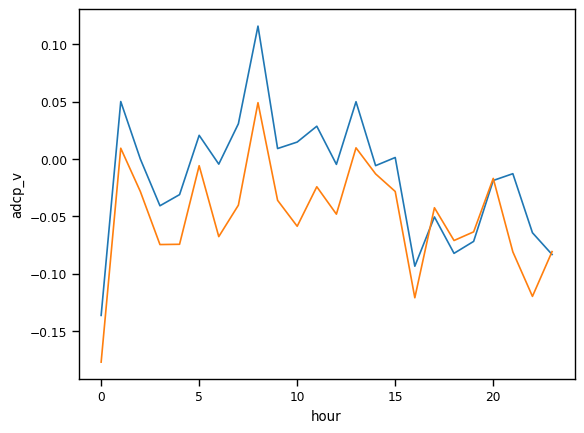

In [23]:
hourly_stage_1.xband_v.plot()
hourly_stage_1.adcp_v.plot()

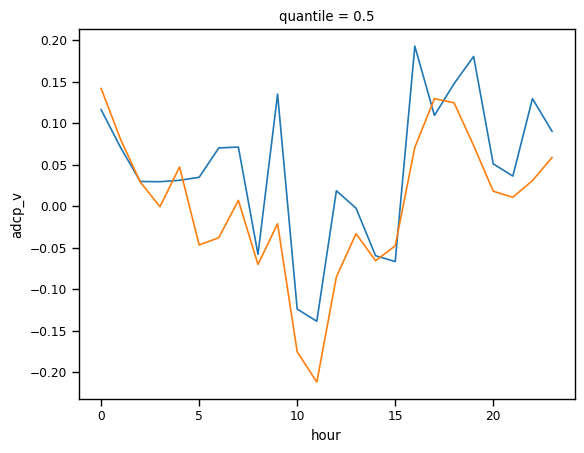

In [86]:
hourly_stage_2.xband_v.plot()
hourly_stage_2.adcp_v.plot()

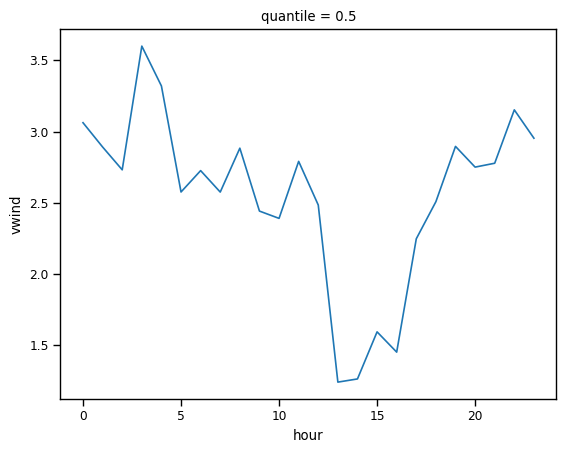

In [87]:
hourly_stage_2.vwind.plot()

In [17]:
ratiou_stage1_day = ds_stage_1.xband_u.where(((hours_stage_1>=9) & (hours_stage_1<=15))) / \
                   ds_stage_1.adcp_u.where(((hours_stage_1>=9) & (hours_stage_1<=15)))
ratiou_stage2_day = ds_stage_2.xband_u.where(((hours_stage_2>=9) & (hours_stage_2<=15))) / \
                   ds_stage_2.adcp_u.where(((hours_stage_2>=9) & (hours_stage_2<=15)))

ratiou_stage1_night = ds_stage_1.xband_u.where(((hours_stage_1<=6) | (hours_stage_1>=22))) / \
                     ds_stage_1.adcp_u.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
ratiou_stage2_night = ds_stage_2.xband_u.where(((hours_stage_2<=6) | (hours_stage_2>=22))) / \
                   ds_stage_2.adcp_u.where(((hours_stage_2<=6) | (hours_stage_2>=22)))

In [18]:
hist_ratiou_stage1_day = np.histogram(ratiou_stage1_day, bins=np.arange(-1, 4.2, 0.2))
hist_ratiou_stage2_day = np.histogram(ratiou_stage2_day, bins=np.arange(-1, 4.2, 0.2))

hist_ratiou_stage1_night = np.histogram(ratiou_stage1_night, bins=np.arange(-1, 4.2, 0.2))
hist_ratiou_stage2_night = np.histogram(ratiou_stage2_night, bins=np.arange(-1, 4.2, 0.2))

In [19]:
ratiov_stage1_day = ds_stage_1.xband_v.where(((hours_stage_1>=9) & (hours_stage_1<=15))) / \
                   ds_stage_1.adcp_v.where(((hours_stage_1>=9) & (hours_stage_1<=15)))
ratiov_stage2_day = ds_stage_2.xband_v.where(((hours_stage_2>=9) & (hours_stage_2<=15))) / \
                   ds_stage_2.adcp_v.where(((hours_stage_2>=9) & (hours_stage_2<=15)))

ratiov_stage1_night = ds_stage_1.xband_v.where(((hours_stage_1<=6) | (hours_stage_1>=22))) / \
                     ds_stage_1.adcp_v.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
ratiov_stage2_night = ds_stage_2.xband_v.where(((hours_stage_2<=6) | (hours_stage_2>=22))) / \
                   ds_stage_2.adcp_v.where(((hours_stage_2<=6) | (hours_stage_2>=22)))

In [20]:
hist_ratiov_stage1_day = np.histogram(ratiov_stage1_day, bins=np.arange(-1, 4.2, 0.2))
hist_ratiov_stage2_day = np.histogram(ratiov_stage2_day, bins=np.arange(-1, 4.2, 0.2))

hist_ratiov_stage1_night = np.histogram(ratiov_stage1_night, bins=np.arange(-1, 4.2, 0.2))
hist_ratiov_stage2_night = np.histogram(ratiov_stage2_night, bins=np.arange(-1, 4.2, 0.2))

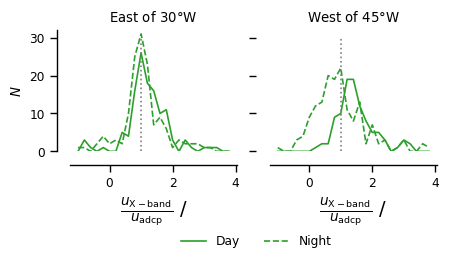

In [21]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_ratiou_stage1_day[1][:-1], hist_ratiou_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_ratiou_stage1_night[1][:-1], hist_ratiou_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.plot([1,1],[0,30],':',color="gray")
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
ax1.set_ylim(0, 32)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')

ax2 = fig.add_subplot(122)
ax2.plot(hist_ratiou_stage2_day[1][:-1], hist_ratiou_stage2_day[0], label='Day',color='tab:green')
ax2.plot(hist_ratiou_stage2_night[1][:-1], hist_ratiou_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.plot([1,1],[0,30],':',color="gray")
ax2.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')

plt.subplots_adjust(hspace=0.8)
plt.savefig('../figures/diurnal_zonal_current_adcp_xband.png',
            format='png',dpi=300,bbox_inches='tight',orientation={'landscape'})

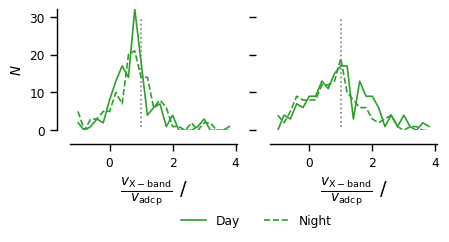

In [23]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_ratiov_stage1_day[1][:-1], hist_ratiov_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_ratiov_stage1_night[1][:-1], hist_ratiov_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{v_{\mathrm{X-band}}}{v_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.plot([1,1],[1,30],':',color="gray")
ax1.set_ylabel("$N$")
ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax2 = fig.add_subplot(122)
ax2.plot(hist_ratiov_stage2_day[1][:-1], hist_ratiov_stage2_day[0], label='Day',color='tab:green')
ax2.plot(hist_ratiov_stage2_night[1][:-1], hist_ratiov_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.set_xlabel(r'$\frac{v_{\mathrm{X-band}}}{v_{\mathrm{adcp}}}$ /',fontsize=14)
ax2.plot([1,1],[1,30],':',color="gray")
ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))

In [22]:
diff_u_xband_adcp_stage1 = ds_stage_1.xband_u - ds_stage_1.adcp_u
diff_u_xband_adcp_stage2 = ds_stage_2.xband_u - ds_stage_2.adcp_u

diff_u_xband_adcp_stage1_day = diff_u_xband_adcp_stage1.where(((hours_stage_1>=9) & (hours_stage_1<=15)))
diff_u_xband_adcp_stage1_night = diff_u_xband_adcp_stage1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
diff_u_xband_adcp_stage2_day = diff_u_xband_adcp_stage2.where(((hours_stage_2>=9) & (hours_stage_2<=15)))
diff_u_xband_adcp_stage2_night = diff_u_xband_adcp_stage2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))

hist_diff_u_xband_adcp_stage1_day = np.histogram(diff_u_xband_adcp_stage1_day, bins=np.arange(-0.5, 0.52, 0.04))
hist_diff_u_xband_adcp_stage1_night = np.histogram(diff_u_xband_adcp_stage1_night, bins=np.arange(-0.5, 0.52, 0.04))
hist_diff_u_xband_adcp_stage2_day = np.histogram(diff_u_xband_adcp_stage2_day, bins=np.arange(-0.5, 0.52, 0.04))
hist_diff_u_xband_adcp_stage2_night = np.histogram(diff_u_xband_adcp_stage2_night, bins=np.arange(-0.5, 0.52, 0.04))

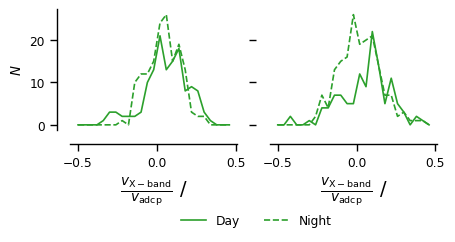

In [23]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_diff_u_xband_adcp_stage1_day[1][:-1], hist_diff_u_xband_adcp_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_diff_u_xband_adcp_stage1_night[1][:-1], hist_diff_u_xband_adcp_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{v_{\mathrm{X-band}}}{v_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
sns.despine(offset=10)

ax2 = fig.add_subplot(122)
ax2.plot(hist_diff_u_xband_adcp_stage2_day[1][:-1], hist_diff_u_xband_adcp_stage2_day[0], label='Day',color='tab:green')
ax2.plot(hist_diff_u_xband_adcp_stage2_night[1][:-1], hist_diff_u_xband_adcp_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.set_xlabel(r'$\frac{v_{\mathrm{X-band}}}{v_{\mathrm{adcp}}}$ /',fontsize=14)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))

In [24]:
diff_dir_adcp_xband_stage1 = dir_adcp_stage1 - dir_xband_stage1
diff_dir_adcp_xband_stage2 = dir_adcp_stage2 - dir_xband_stage2

diff_dir_adcp_xband_stage1_day = diff_dir_adcp_xband_stage1.where(((hours_stage_1>=9) & (hours_stage_1<=15)))
diff_dir_adcp_xband_stage2_day = diff_dir_adcp_xband_stage2.where(((hours_stage_2>=9) & (hours_stage_2<=15)))
diff_dir_adcp_xband_stage1_night = diff_dir_adcp_xband_stage1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
diff_dir_adcp_xband_stage2_night = diff_dir_adcp_xband_stage2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))


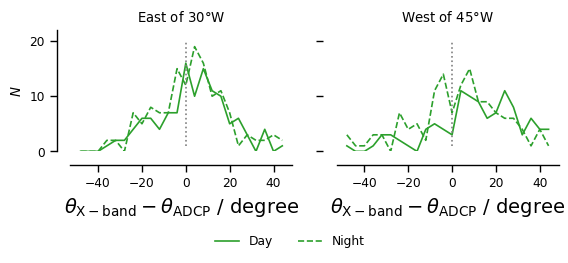

In [25]:
hist_diff_dir_stage1_day = np.histogram(diff_dir_adcp_xband_stage1_day, bins=np.arange(-48, 49, 4))
hist_diff_dir_stage2_day = np.histogram(diff_dir_adcp_xband_stage2_day, bins=np.arange(-48, 49, 4))
hist_diff_dir_stage1_night = np.histogram(diff_dir_adcp_xband_stage1_night, bins=np.arange(-48, 49, 4))
hist_diff_dir_stage2_night = np.histogram(diff_dir_adcp_xband_stage2_night, bins=np.arange(-48, 49, 4))
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_diff_dir_stage1_day[1][:-1], hist_diff_dir_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_diff_dir_stage1_night[1][:-1], hist_diff_dir_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\theta_{\mathrm{X-band}}-\theta_{\mathrm{ADCP}}$ / degree',fontsize=14)
ax1.plot([0,0],[1,20],':',color="gray")
ax1.set_ylabel("$N$")
ax1.set_ylim(0, 22)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')   
ax2 = fig.add_subplot(122)
ax2.plot(hist_diff_dir_stage2_day[1][:-1], hist_diff_dir_stage2_day[0], label='Day',color='tab:green')
ax2.plot(hist_diff_dir_stage2_night[1][:-1], hist_diff_dir_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.set_xlabel(r'$\theta_{\mathrm{X-band}}-\theta_{\mathrm{ADCP}}$ / degree',fontsize=14)
ax2.plot([0,0],[1,20],':',color="gray")
ax2.set_ylim(0, 22)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')
plt.subplots_adjust(hspace=0.8)


In [28]:
cross_adcp_wind_s1, cross_xband_wind_s1, long_adcp_wind_s1, long_xband_wind_s1 = calculate_current_cross_along(
    ds_stage_1.adcp_u, ds_stage_1.adcp_v, ds_stage_1.xband_u, ds_stage_1.xband_v, dir_wind_stage1)

In [29]:
cross_adcp_wind_s2, cross_xband_wind_s2, long_adcp_wind_s2, long_xband_wind_s2 = calculate_current_cross_along(
    ds_stage_2.adcp_u, ds_stage_2.adcp_v, ds_stage_2.xband_u, ds_stage_2.xband_v, dir_wind_stage2)

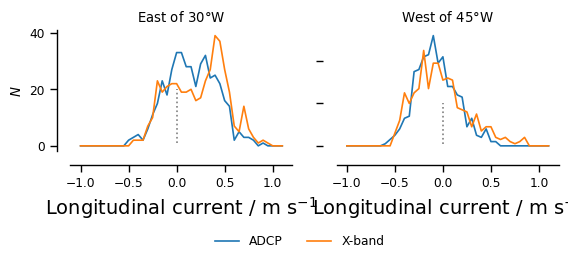

In [30]:
hist_long_adcp_wind_s1 = np.histogram(long_adcp_wind_s1, bins=np.arange(-1, 1.2, 0.05))
hist_long_adcp_wind_s2 = np.histogram(long_adcp_wind_s2, bins=np.arange(-1, 1.2, 0.05))
hist_long_xband_wind_s1 = np.histogram(long_xband_wind_s1, bins=np.arange(-1, 1.2, 0.05))
hist_long_xband_wind_s2 = np.histogram(long_xband_wind_s2, bins=np.arange(-1, 1.2, 0.05))
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_long_adcp_wind_s1[1][:-1], hist_long_adcp_wind_s1[0], label=r'ADCP',color='tab:blue')
ax1.plot(hist_long_xband_wind_s1[1][:-1], hist_long_xband_wind_s1[0], label=r'X-band',color='tab:orange')
ax1.set_xlabel(r'Longitudinal current / m s$^{-1}$',fontsize=14)
ax1.plot([0,0],[1,20],':',color="gray")
ax1.set_ylabel("$N$")
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')
ax2 = fig.add_subplot(122)
ax2.plot(hist_long_adcp_wind_s2[1][:-1], hist_long_adcp_wind_s2[0], label=r'ADCP',color='tab:blue')
ax2.plot(hist_long_xband_wind_s2[1][:-1], hist_long_xband_wind_s2[0], label=r'X-band',color='tab:orange')
ax2.set_xlabel(r'Longitudinal current / m s$^{-1}$',fontsize=14)
ax2.plot([0,0],[1,20],':',color="gray")
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')
plt.subplots_adjust(hspace=0.8)

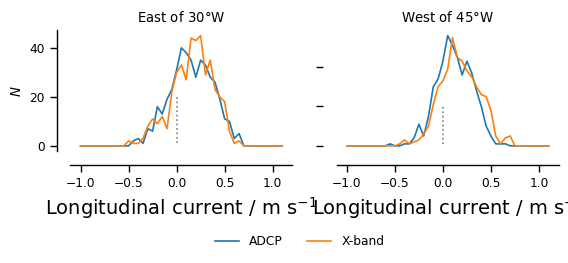

In [31]:
hist_cross_adcp_wind_s1 = np.histogram(cross_adcp_wind_s1, bins=np.arange(-1, 1.2, 0.05))
hist_cross_adcp_wind_s2 = np.histogram(cross_adcp_wind_s2, bins=np.arange(-1, 1.2, 0.05))
hist_cross_xband_wind_s1 = np.histogram(cross_xband_wind_s1, bins=np.arange(-1, 1.2, 0.05))
hist_cross_xband_wind_s2 = np.histogram(cross_xband_wind_s2, bins=np.arange(-1, 1.2, 0.05))
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_cross_adcp_wind_s1[1][:-1], hist_cross_adcp_wind_s1[0], label=r'ADCP',color='tab:blue')
ax1.plot(hist_cross_xband_wind_s1[1][:-1], hist_cross_xband_wind_s1[0], label=r'X-band',color='tab:orange')
ax1.set_xlabel(r'Longitudinal current / m s$^{-1}$',fontsize=14)
ax1.plot([0,0],[1,20],':',color="gray")
ax1.set_ylabel("$N$")
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')
ax2 = fig.add_subplot(122)
ax2.plot(hist_cross_adcp_wind_s2[1][:-1], hist_cross_adcp_wind_s2[0], label=r'ADCP',color='tab:blue')
ax2.plot(hist_cross_xband_wind_s2[1][:-1], hist_cross_xband_wind_s2[0], label=r'X-band',color='tab:orange')
ax2.set_xlabel(r'Longitudinal current / m s$^{-1}$',fontsize=14)
ax2.plot([0,0],[1,20],':',color="gray")
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')
plt.subplots_adjust(hspace=0.8)

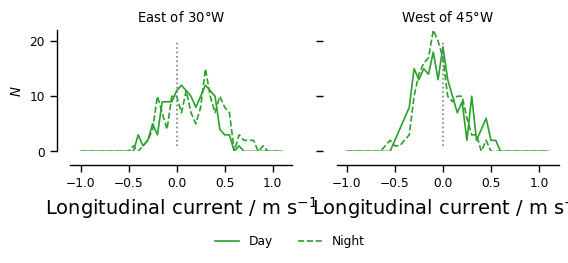

In [32]:
long_adcp_wind_s1_day = long_adcp_wind_s1.where(((hours_stage_1>=12) & (hours_stage_1<=19)))
long_adcp_wind_s2_day = long_adcp_wind_s2.where(((hours_stage_2>=12) & (hours_stage_2<=19)))
long_adcp_wind_s1_night = long_adcp_wind_s1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
long_adcp_wind_s2_night = long_adcp_wind_s2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))
hist_long_adcp_wind_s1_day = np.histogram(long_adcp_wind_s1_day, bins=np.arange(-1, 1.2, 0.05))
hist_long_adcp_wind_s2_day = np.histogram(long_adcp_wind_s2_day, bins=np.arange(-1, 1.2, 0.05))
hist_long_adcp_wind_s1_night = np.histogram(long_adcp_wind_s1_night, bins=np.arange(-1, 1.2, 0.05))
hist_long_adcp_wind_s2_night = np.histogram(long_adcp_wind_s2_night, bins=np.arange(-1, 1.2, 0.05))
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_long_adcp_wind_s1_day[1][:-1], hist_long_adcp_wind_s1_day[0], label='Day',color='tab:green')
ax1.plot(hist_long_adcp_wind_s1_night[1][:-1], hist_long_adcp_wind_s1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'Longitudinal current / m s$^{-1}$',fontsize=14)
ax1.plot([0,0],[1,20],':',color="gray")
ax1.set_ylabel("$N$")
ax1.set_ylim(0, 22)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')
ax2 = fig.add_subplot(122)
ax2.plot(hist_long_adcp_wind_s2_day[1][:-1], hist_long_adcp_wind_s2_day[0], label='Day',color='tab:green')
ax2.plot(hist_long_adcp_wind_s2_night[1][:-1], hist_long_adcp_wind_s2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.set_xlabel(r'Longitudinal current / m s$^{-1}$',fontsize=14)
ax2.plot([0,0],[1,20],':',color="gray")
ax2.set_ylim(0, 22)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')
plt.subplots_adjust(hspace=0.8)

In [33]:
ratio_long_wind_s1 = long_xband_wind_s1 / long_adcp_wind_s1
ratio_long_wind_s2 = long_xband_wind_s2 / long_adcp_wind_s2

ratio_cross_wind_s1 = cross_xband_wind_s1 / cross_adcp_wind_s1
ratio_cross_wind_s2 = cross_xband_wind_s2 / cross_adcp_wind_s2

diff_long_wind_s1 = long_xband_wind_s1 - long_adcp_wind_s1
diff_long_wind_s2 = long_xband_wind_s2 - long_adcp_wind_s2

diff_cross_wind_s1 = cross_xband_wind_s1 - cross_adcp_wind_s1
diff_cross_wind_s2 = cross_xband_wind_s2 - cross_adcp_wind_s2

In [34]:
ratio_long_wind_s1_day = ratio_long_wind_s1.where(((hours_stage_1>=9) & (hours_stage_1<=15))) 
ratio_long_wind_s2_day = ratio_long_wind_s2.where(((hours_stage_2>=9) & (hours_stage_2<=15))) 
ratio_long_wind_s1_night = ratio_long_wind_s1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
ratio_long_wind_s2_night = ratio_long_wind_s2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))

hist_ratio_long_wind_s1_day = np.histogram(ratio_long_wind_s1_day, bins=np.arange(-1, 4.2, 0.2))
hist_ratio_long_wind_s2_day = np.histogram(ratio_long_wind_s2_day, bins=np.arange(-2, 4.2, 0.2))
hist_ratio_long_wind_s1_night = np.histogram(ratio_long_wind_s1_night, bins=np.arange(-2, 4.2, 0.2))
hist_ratio_long_wind_s2_night = np.histogram(ratio_long_wind_s2_night, bins=np.arange(-2, 4.2, 0.2))

Text(0.5, 1.0, 'West of 45$\\degree$W')

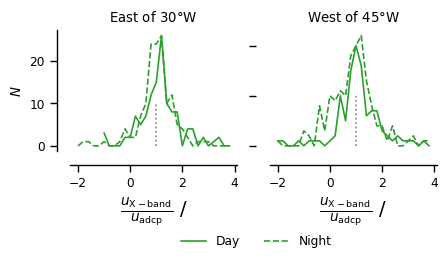

In [35]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_ratio_long_wind_s1_day[1][:-1], hist_ratio_long_wind_s1_day[0], label='Day',color='tab:green')
ax1.plot(hist_ratio_long_wind_s1_night[1][:-1], hist_ratio_long_wind_s1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.plot([1,1],[0,10],':',color="gray")
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')

ax2 = fig.add_subplot(122)
ax2.plot(hist_ratio_long_wind_s2_day[1][:-1], hist_ratio_long_wind_s2_day[0], label='Day',color='tab:green')
ax2.plot(hist_ratio_long_wind_s2_night[1][:-1], hist_ratio_long_wind_s2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.plot([1,1],[0,10],':',color="gray")
ax2.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
#ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')

Text(0.5, 1.0, 'West of 45$\\degree$W')

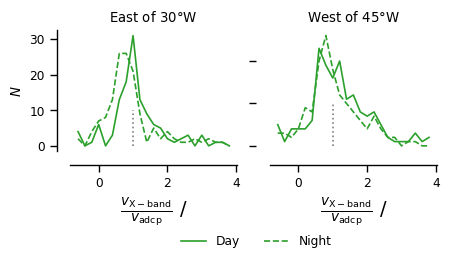

In [57]:
ratio_cross_wind_s1_day = ratio_cross_wind_s1.where(((hours_stage_1>=12) & (hours_stage_1<=19)))
ratio_cross_wind_s2_day = ratio_cross_wind_s2.where(((hours_stage_2>=12) & (hours_stage_2<=19)))
ratio_cross_wind_s1_night = ratio_cross_wind_s1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
ratio_cross_wind_s2_night = ratio_cross_wind_s2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))
hist_ratio_cross_wind_s1_day = np.histogram(ratio_cross_wind_s1_day, bins=np.arange(-0.6, 4.2, 0.2))
hist_ratio_cross_wind_s2_day = np.histogram(ratio_cross_wind_s2_day, bins=np.arange(-0.6, 4.2, 0.2))
hist_ratio_cross_wind_s1_night = np.histogram(ratio_cross_wind_s1_night, bins=np.arange(-0.6, 4.2, 0.2))
hist_ratio_cross_wind_s2_night = np.histogram(ratio_cross_wind_s2_night, bins=np.arange(-0.6, 4.2, 0.2))
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_ratio_cross_wind_s1_day[1][:-1], hist_ratio_cross_wind_s1_day[0], label='Day',color='tab:green')
ax1.plot(hist_ratio_cross_wind_s1_night[1][:-1], hist_ratio_cross_wind_s1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.plot([1,1],[0,10],':',color="gray")
ax1.set_xlabel(r'$\frac{v_{\mathrm{X-band}}}{v_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W') 
ax2 = fig.add_subplot(122)
ax2.plot(hist_ratio_cross_wind_s2_day[1][:-1], hist_ratio_cross_wind_s2_day[0], label='Day',color='tab:green')
ax2.plot(hist_ratio_cross_wind_s2_night[1][:-1], hist_ratio_cross_wind_s2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.plot([1,1],[0,10],':',color="gray")
ax2.set_xlabel(r'$\frac{v_{\mathrm{X-band}}}{v_{\mathrm{adcp}}}$ /',fontsize=14)
#ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')

In [36]:
diff_long_wind_s1_day = diff_long_wind_s1.where(((hours_stage_1>=9) & (hours_stage_1<=15)))
diff_long_wind_s2_day = diff_long_wind_s2.where(((hours_stage_2>=9) & (hours_stage_2<=15)))
diff_long_wind_s1_night = diff_long_wind_s1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
diff_long_wind_s2_night = diff_long_wind_s2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))
hist_diff_long_wind_s1_day = np.histogram(diff_long_wind_s1_day, bins=np.arange(-0.52, 0.65, 0.04))
hist_diff_long_wind_s2_day = np.histogram(diff_long_wind_s2_day, bins=np.arange(-0.52, 0.65, 0.04))
hist_diff_long_wind_s1_night = np.histogram(diff_long_wind_s1_night, bins=np.arange(-0.52, 0.65, 0.04))
hist_diff_long_wind_s2_night = np.histogram(diff_long_wind_s2_night, bins=np.arange(-0.52, 0.65, 0.04))

Text(0.5, 1.0, 'West of 45$\\degree$W')

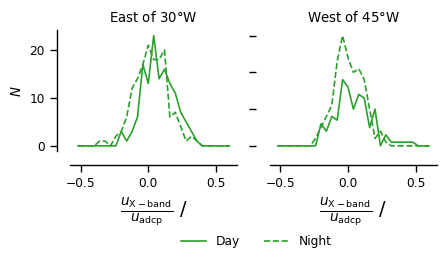

In [37]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_diff_long_wind_s1_day[1][:-1], hist_diff_long_wind_s1_day[0], label='Day',color='tab:green')
ax1.plot(hist_diff_long_wind_s1_night[1][:-1], hist_diff_long_wind_s1_night[0], label='Night',color='tab:green',linestyle='--')
#ax1.plot([1,1],[0,10],':',color="gray")
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')

ax2 = fig.add_subplot(122)
ax2.plot(hist_diff_long_wind_s2_day[1][:-1], hist_diff_long_wind_s2_day[0], label='Day',color='tab:green')
ax2.plot(hist_diff_long_wind_s2_night[1][:-1], hist_diff_long_wind_s2_night[0], label='Night',color='tab:green',linestyle='--')
#ax2.plot([1,1],[0,10],':',color="gray")
ax2.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
#ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))
ax2.set_title(r'West of 45$\degree$W')

In [38]:
diff_cross_wind_s1_day = diff_cross_wind_s1.where(((hours_stage_1>=9) & (hours_stage_1<=15)))
diff_cross_wind_s2_day = diff_cross_wind_s2.where(((hours_stage_2>=9) & (hours_stage_2<=15)))
diff_cross_wind_s1_night = diff_cross_wind_s1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
diff_cross_wind_s2_night = diff_cross_wind_s2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))
hist_diff_cross_wind_s1_day = np.histogram(diff_cross_wind_s1_day, bins=np.arange(-0.52, 0.65, 0.04))
hist_diff_cross_wind_s2_day = np.histogram(diff_cross_wind_s2_day, bins=np.arange(-0.52, 0.65, 0.04))
hist_diff_cross_wind_s1_night = np.histogram(diff_cross_wind_s1_night, bins=np.arange(-0.52, 0.65, 0.04))
hist_diff_cross_wind_s2_night = np.histogram(diff_cross_wind_s2_night, bins=np.arange(-0.52, 0.65, 0.04))

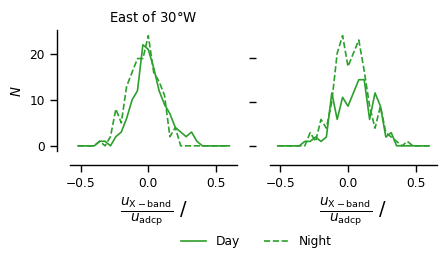

In [39]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_diff_cross_wind_s1_day[1][:-1], hist_diff_cross_wind_s1_day[0], label='Day',color='tab:green')
ax1.plot(hist_diff_cross_wind_s1_night[1][:-1], hist_diff_cross_wind_s1_night[0], label='Night',color='tab:green',linestyle='--')
#ax1.plot([1,1],[0,10],':',color="gray")
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)
ax1.set_title(r'East of 30$\degree$W')

ax2 = fig.add_subplot(122)
ax2.plot(hist_diff_cross_wind_s2_day[1][:-1], hist_diff_cross_wind_s2_day[0], label='Day',color='tab:green')
ax2.plot(hist_diff_cross_wind_s2_night[1][:-1], hist_diff_cross_wind_s2_night[0], label='Night',color='tab:green',linestyle='--')
#ax2.plot([1,1],[0,10],':',color="gray")
ax2.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{adcp}}}$ /',fontsize=14)
#ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))

/var/folders/l3/7mstk0nx3_3c69r4z8lzlp0w0000gp/T/ipykernel_2050/894216140.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([-0.5, 1], [-0.5, 1], 'k--', label='Reference', color='tab:blue')


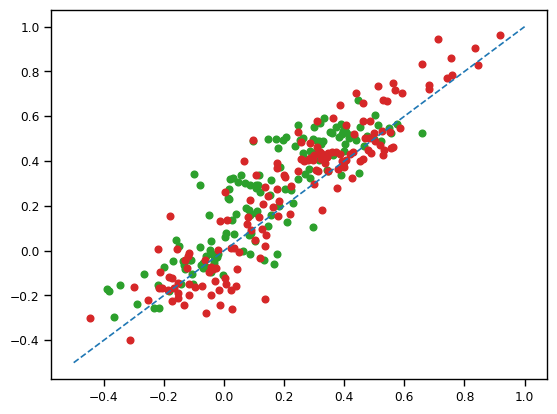

In [ ]:
plt.plot(long_adcp_wind_s1_day, long_xband_wind_s1_day, 'o', label='Day', color='tab:green')
plt.plot(long_adcp_wind_s1_night, long_xband_wind_s1_night, 'o', label='Night', color='tab:red')
plt.plot([-0.5, 1], [-0.5, 1], 'k--', label='Reference', color='tab:blue')

/var/folders/l3/7mstk0nx3_3c69r4z8lzlp0w0000gp/T/ipykernel_2050/706332018.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([-0.5, 1], [-0.5, 1], 'k--', label='Reference', color='tab:blue')


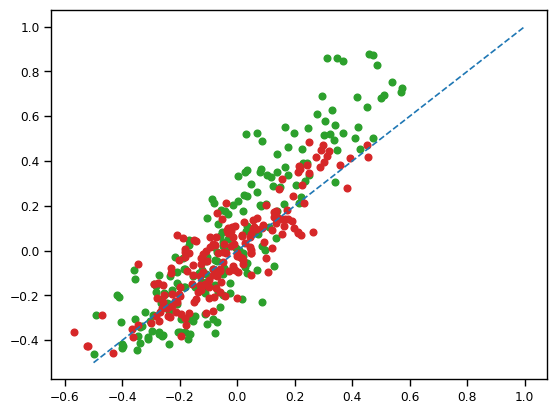

In [27]:
plt.plot(long_adcp_wind_s2_day, long_xband_wind_s2_day, 'o', label='Day', color='tab:green')
plt.plot(long_adcp_wind_s2_night, long_xband_wind_s2_night, 'o', label='Night', color='tab:red')
plt.plot([-0.5, 1], [-0.5, 1], 'k--', label='Reference', color='tab:blue')

In [34]:
diff_dir_wind_xband_stage1 = dir_wind_stage1 - dir_xband_stage1
diff_dir_wind_xband_stage2 = dir_wind_stage2 - dir_xband_stage2
diff_dir_wind_adcp_stage1 = dir_wind_stage1 - dir_adcp_stage1
diff_dir_wind_adcp_stage2 = dir_wind_stage2 - dir_adcp_stage2

diff_dir_wind_xband_stage1_day = diff_dir_wind_xband_stage1.where(((hours_stage_1>=12) & (hours_stage_1<=19)))
diff_dir_wind_xband_stage1_night = diff_dir_wind_xband_stage1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
diff_dir_wind_xband_stage2_day = diff_dir_wind_xband_stage2.where(((hours_stage_2>=12) & (hours_stage_2<=19)))
diff_dir_wind_xband_stage2_night = diff_dir_wind_xband_stage2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))
diff_dir_wind_adcp_stage1_day = diff_dir_wind_adcp_stage1.where(((hours_stage_1>=12) & (hours_stage_1<=19)))
diff_dir_wind_adcp_stage1_night = diff_dir_wind_adcp_stage1.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
diff_dir_wind_adcp_stage2_day = diff_dir_wind_adcp_stage2.where(((hours_stage_2>=12) & (hours_stage_2<=19)))
diff_dir_wind_adcp_stage2_night = diff_dir_wind_adcp_stage2.where(((hours_stage_2<=6) | (hours_stage_2>=22)))


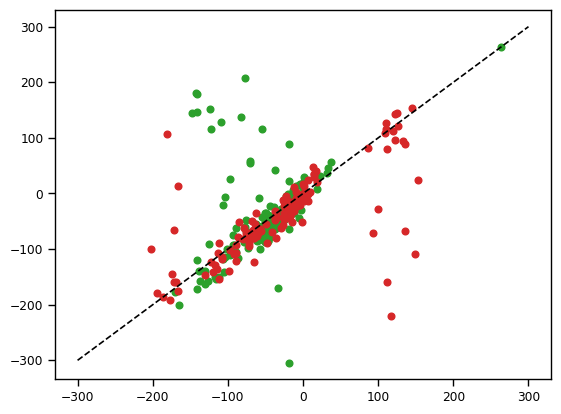

In [39]:
plt.plot(diff_dir_wind_xband_stage1_day, diff_dir_wind_adcp_stage1_day, 'o', label='Day',color='tab:green')
plt.plot(diff_dir_wind_xband_stage1_night, diff_dir_wind_adcp_stage1_night, 'o', label='Night',color='tab:red')
plt.plot([-300,300],[-300,300],'--k')

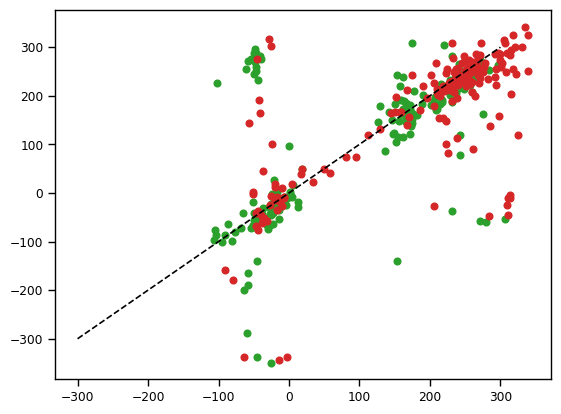

In [40]:
plt.plot(diff_dir_wind_xband_stage2_day, diff_dir_wind_adcp_stage2_day, 'o', label='Day',color='tab:green')
plt.plot(diff_dir_wind_xband_stage2_night, diff_dir_wind_adcp_stage2_night, 'o', label='Night',color='tab:red')
plt.plot([-300,300],[-300,300],'--k')

In [102]:
ratiom_stage1_day = ds_stage_1.xband_u.where(((hours_stage_1>=12) & (hours_stage_1<=19))) / \
                   ds_stage_1.uwind.where(((hours_stage_1>=12) & (hours_stage_1<=19)))
ratiom_stage2_day = ds_stage_2.xband_u.where(((hours_stage_2>=12) & (hours_stage_2<=19))) / \
                   ds_stage_2.uwind.where(((hours_stage_2>=12) & (hours_stage_2<=19)))

ratiom_stage1_night = ds_stage_1.xband_u.where(((hours_stage_1<=6) | (hours_stage_1>=22))) / \
                     ds_stage_1.uwind.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
ratiom_stage2_night = ds_stage_2.xband_u.where(((hours_stage_2<=6) | (hours_stage_2>=22))) / \
                   ds_stage_2.uwind.where(((hours_stage_2<=6) | (hours_stage_2>=22)))

In [117]:
hist_ratiom_stage1_day = np.histogram(ratiom_stage1_day, bins=np.arange(-0.28, 0.3, 0.02))
hist_ratiom_stage2_day = np.histogram(ratiom_stage2_day, bins=np.arange(-0.28, 0.3, 0.02))

hist_ratiom_stage1_night = np.histogram(ratiom_stage1_night, bins=np.arange(-0.28, 0.3, 0.02))
hist_ratiom_stage2_night = np.histogram(ratiom_stage2_night, bins=np.arange(-0.28, 0.3, 0.02))

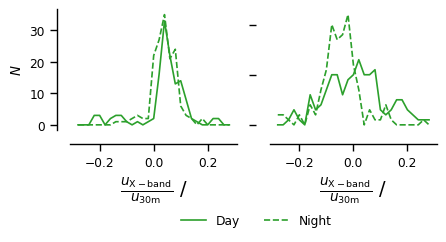

In [119]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_ratiom_stage1_day[1][:-1], hist_ratiom_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_ratiom_stage1_night[1][:-1], hist_ratiom_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax2 = fig.add_subplot(122)
ax2.plot(hist_ratiom_stage2_day[1][:-1], hist_ratiom_stage2_day[0], label='Day',color='tab:green')
ax2.plot(hist_ratiom_stage2_night[1][:-1], hist_ratiom_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
#ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))

In [121]:
ratiovm_stage1_day = ds_stage_1.xband_v.where(((hours_stage_1>=12) & (hours_stage_1<=19))) / \
                   ds_stage_1.vwind.where(((hours_stage_1>=12) & (hours_stage_1<=19)))
ratiovm_stage2_day = ds_stage_2.xband_v.where(((hours_stage_2>=12) & (hours_stage_2<=19))) / \
                   ds_stage_2.vwind.where(((hours_stage_2>=12) & (hours_stage_2<=19)))

ratiovm_stage1_night = ds_stage_1.xband_v.where(((hours_stage_1<=6) | (hours_stage_1>=22))) / \
                     ds_stage_1.vwind.where(((hours_stage_1<=6) | (hours_stage_1>=22)))
ratiovm_stage2_night = ds_stage_2.xband_v.where(((hours_stage_2<=6) | (hours_stage_2>=22))) / \
                   ds_stage_2.vwind.where(((hours_stage_2<=6) | (hours_stage_2>=22)))

In [122]:
hist_ratiovm_stage1_day = np.histogram(ratiovm_stage1_day, bins=np.arange(-0.28, 0.3, 0.02))
hist_ratiovm_stage2_day = np.histogram(ratiovm_stage2_day, bins=np.arange(-0.28, 0.3, 0.02))

hist_ratiovm_stage1_night = np.histogram(ratiovm_stage1_night, bins=np.arange(-0.28, 0.3, 0.02))
hist_ratiovm_stage2_night = np.histogram(ratiovm_stage2_night, bins=np.arange(-0.28, 0.3, 0.02))

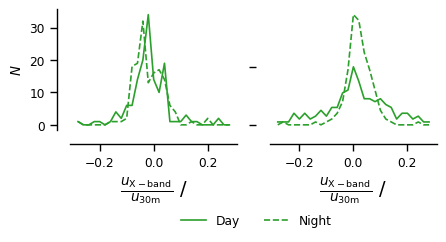

In [123]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_ratiovm_stage1_day[1][:-1], hist_ratiovm_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_ratiovm_stage1_night[1][:-1], hist_ratiovm_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax2 = fig.add_subplot(122)
ax2.plot(hist_ratiovm_stage2_day[1][:-1], hist_ratiovm_stage2_day[0], label='Day',color='tab:green')
ax2.plot(hist_ratiovm_stage2_night[1][:-1], hist_ratiovm_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax2.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
#ax2.set_ylim(0, 32)
ax2.set_yticklabels({})
sns.despine(offset=10)
ax2.spines['left'].set_visible(False)
ax2.legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(-0.6,-0.6))

In [173]:
hist_uwind_stage1_day = np.histogram(ds_stage_1.uwind.where(((hours_stage_1>=12) & (hours_stage_1<=19))), bins=np.arange(-10, 14.5, 0.5))
hist_uwind_stage1_night = np.histogram(ds_stage_1.uwind.where(((hours_stage_1<=6) | (hours_stage_1>=22))), bins=np.arange(-10, 14.5, 0.5))
hist_vwind_stage1_day = np.histogram(ds_stage_1.vwind.where(((hours_stage_1>=12) & (hours_stage_1<=19))), bins=np.arange(-10, 14.5, 0.5))
hist_vwind_stage1_night = np.histogram(ds_stage_1.vwind.where(((hours_stage_1<=6) | (hours_stage_1>=22))), bins=np.arange(-10, 14.5, 0.5))

hist_uwind_stage2_day = np.histogram(ds_stage_2.uwind.where(((hours_stage_2>=12) & (hours_stage_2<=19))), bins=np.arange(-10, 14.5, 0.5))
hist_uwind_stage2_night = np.histogram(ds_stage_2.uwind.where(((hours_stage_2<=6) | (hours_stage_2>=22))), bins=np.arange(-10, 14.5, 0.5))
hist_vwind_stage2_day = np.histogram(ds_stage_2.vwind.where(((hours_stage_2>=12) & (hours_stage_2<=19))), bins=np.arange(-10, 14.5, 0.5))
hist_vwind_stage2_night = np.histogram(ds_stage_2.vwind.where(((hours_stage_2<=6) | (hours_stage_2>=22))), bins=np.arange(-10, 14.5, 0.5))

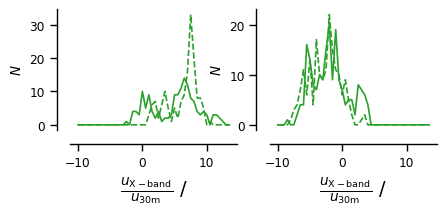

In [174]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_uwind_stage1_day[1][:-1], hist_uwind_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_uwind_stage1_night[1][:-1], hist_uwind_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax1 = fig.add_subplot(122)
ax1.plot(hist_uwind_stage2_day[1][:-1], hist_uwind_stage2_day[0], label='Day',color='tab:green')
ax1.plot(hist_uwind_stage2_night[1][:-1], hist_uwind_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

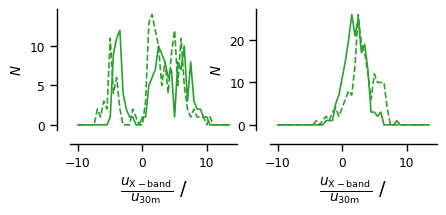

In [179]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_vwind_stage1_day[1][:-1], hist_vwind_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_vwind_stage1_night[1][:-1], hist_vwind_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax1 = fig.add_subplot(122)
ax1.plot(hist_vwind_stage2_day[1][:-1], hist_vwind_stage2_day[0], label='Day',color='tab:green')
ax1.plot(hist_vwind_stage2_night[1][:-1], hist_vwind_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

In [177]:
hist_uxband_stage1_day = np.histogram(ds_stage_1.xband_u.where(((hours_stage_1>=12) & (hours_stage_1<=19))), bins=np.arange(-1, 1.4, 0.05))
hist_uxband_stage1_night = np.histogram(ds_stage_1.xband_u.where(((hours_stage_1<=6) | (hours_stage_1>=22))), bins=np.arange(-1, 1.4, 0.05))
hist_uxband_stage2_day = np.histogram(ds_stage_2.xband_u.where(((hours_stage_2>=12) & (hours_stage_2<=19))), bins=np.arange(-1, 1.4, 0.05))
hist_uxband_stage2_night = np.histogram(ds_stage_2.xband_u.where(((hours_stage_2<=6) | (hours_stage_2>=22))), bins=np.arange(-1, 1.4, 0.05))


In [180]:
hist_vxband_stage1_day = np.histogram(ds_stage_1.xband_v.where(((hours_stage_1>=12) & (hours_stage_1<=19))), bins=np.arange(-1, 1.4, 0.05))
hist_vxband_stage1_night = np.histogram(ds_stage_1.xband_v.where(((hours_stage_1<=6) | (hours_stage_1>=22))), bins=np.arange(-1, 1.4, 0.05))
hist_vxband_stage2_day = np.histogram(ds_stage_2.xband_v.where(((hours_stage_2>=12) & (hours_stage_2<=19))), bins=np.arange(-1, 1.4, 0.05))
hist_vxband_stage2_night = np.histogram(ds_stage_2.xband_v.where(((hours_stage_2<=6) | (hours_stage_2>=22))), bins=np.arange(-1, 1.4, 0.05))


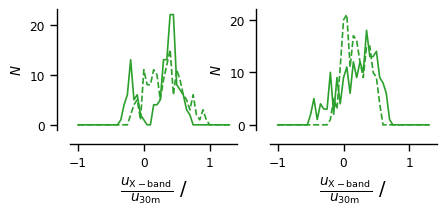

In [182]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_uxband_stage1_day[1][:-1], hist_uxband_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_uxband_stage1_night[1][:-1], hist_uxband_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax1 = fig.add_subplot(122)
ax1.plot(hist_uxband_stage2_day[1][:-1], hist_uxband_stage2_day[0], label='Day',color='tab:green')
ax1.plot(hist_uxband_stage2_night[1][:-1], hist_uxband_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

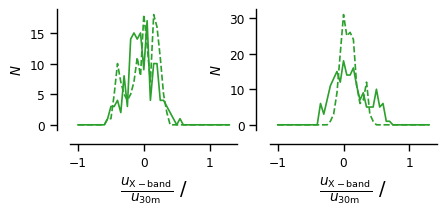

In [181]:
sns.set_context("paper")
fig = plt.figure(figsize=(12/2.54,4/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(hist_vxband_stage1_day[1][:-1], hist_vxband_stage1_day[0], label='Day',color='tab:green')
ax1.plot(hist_vxband_stage1_night[1][:-1], hist_vxband_stage1_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

ax1 = fig.add_subplot(122)
ax1.plot(hist_vxband_stage2_day[1][:-1], hist_vxband_stage2_day[0], label='Day',color='tab:green')
ax1.plot(hist_vxband_stage2_night[1][:-1], hist_vxband_stage2_night[0], label='Night',color='tab:green',linestyle='--')
ax1.set_xlabel(r'$\frac{u_{\mathrm{X-band}}}{u_{\mathrm{30m}}}$ /',fontsize=14)
ax1.set_ylabel("$N$")
#ax1.set_ylim(0, 32)
sns.despine(offset=10)

In [161]:
def calculate_current_cross_along(adcp_u, adcp_v, xband_u, xband_v, heading):
    """
    Calculate the current cross-along values.
    """
    # Calculate the cross-along current
    cross_adcp = (adcp_u) * np.cos(np.radians(heading)) - (adcp_v) * np.sin(np.radians(heading))
    cross_xband = (xband_u) * np.cos(np.radians(heading)) - (xband_v) * np.sin(np.radians(heading))
    long_adcp = (adcp_u) * np.sin(np.radians(heading)) + (adcp_v) * np.cos(np.radians(heading))
    long_xband = (xband_u) * np.sin(np.radians(heading)) + (xband_v) * np.cos(np.radians(heading))
    return cross_adcp, cross_xband, long_adcp, long_xband

In [37]:
def calculate_velocity_magnitude(u, v):
    """
    Calculate the velocity magnitude from u and v components.
    """
    return np.sqrt(u**2 + v**2)

def calculate_direction(u, v):
    """
    Calculate the direction of the current from u and v components.
    """
    return (np.rad2deg(np.arctan2(u, v)) + 360) % 360

def calculate_current_mag_dir(u, v):
    """
    Calculate the current magnitude and direction from u and v components.
    """
    magnitude = calculate_velocity_magnitude(u, v)
    direction = calculate_direction(u, v)
    return magnitude, direction

In [ ]:
cross_adcp_ctd, cross_xband_ctd, long_adcp_ctd, long_xband_ctd = calculate_current_cross_along(
    adcp_u_ctd, adcp_v_ctd, xband_u_ctd, xband_v_ctd, heading_ctd
)
cross_adcp_stage1, cross_xband_stage1, long_adcp_stage1, long_xband_stage1 = calculate_current_cross_along(
    adcp_u_stage1, adcp_v_stage1, xband_u_stage1, xband_v_stage1, heading_stage1
)

In [ ]:
vel_adcp_ctd, dir_adcp_ctd = calculate_current_mag_dir(ds.adcp_u_ctd, ds.adcp_v_ctd)
vel_xband_ctd, dir_xband_ctd = calculate_current_mag_dir(ds.xband_u_ctd, ds.xband_v_ctd)
vel_adcp_stage1, dir_adcp_stage1 = calculate_current_mag_dir(ds.adcp_u_stage1, ds.adcp_v_stage1)
vel_xband_stage1, dir_xband_stage1 = calculate_current_mag_dir(ds.xband_u_stage1, ds.xband_v_stage1)

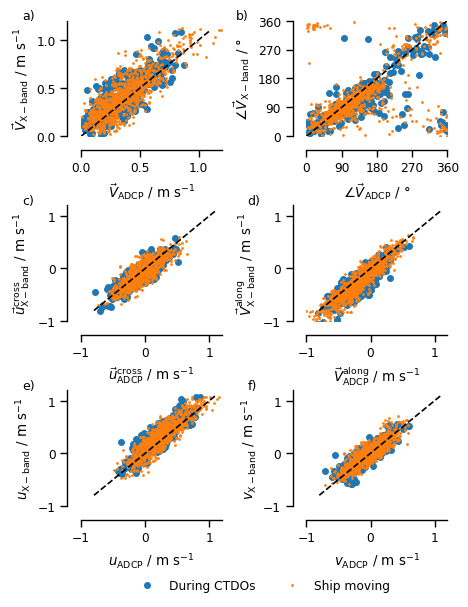

In [295]:
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(321)
ax1.plot(vel_adcp_ctd,vel_xband_ctd,'o',markersize=4,label='During CTDs')
ax1.plot(vel_adcp_stage1,vel_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax1.plot([0,1.1],[0,1.1],'k--')
ax1.set_xlim(0,1.2)
ax1.set_ylim(0,1.2)
ax1.set_yticks([0,0.5,1])
ax1.set_xticks([0,0.5,1])
ax1.set_ylabel(r'$\vec{V}_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$\vec{V}_{\mathrm{ADCP}}$ / m s$^{-1}$')
sns.despine(offset=10,ax=ax1)
plt.text(-0.42, 1.1, 'a)', transform=ax1.transAxes, fontsize=9, va='top', ha='left')

ax2 = fig.add_subplot(322)
ax2.plot(dir_adcp_ctd,dir_xband_ctd,'o',markersize=4,label='During CTDs')
ax2.plot(dir_adcp_stage1,dir_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax2.plot([0,360],[0,360],'k--')
ax2.set_xlim(0,360)
ax2.set_ylim(0,360)
ax2.set_yticks([0,90,180,270,360])
ax2.set_xticks([0,90,180,270,360])
sns.despine(offset=10,ax=ax2)
ax2.set_ylabel(r'$\angle \vec{V}_{\mathrm{X-band}}$ / $\degree$')
ax2.set_xlabel(r'$\angle  \vec{V}_{\mathrm{ADCP}}$ / $\degree$')
plt.text(-0.5, 1.1, 'b)', transform=ax2.transAxes, fontsize=9, va='top', ha='left')

ax3 = fig.add_subplot(323)
ax3.plot(cross_adcp_ctd,cross_xband_ctd,'o',markersize=4,label='During CTDs')
ax3.plot(cross_adcp_stage1,cross_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax3.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax3.set_xlim(-1,1.2)
ax3.set_ylim(-1,1.2)
ax3.set_yticks([-1,0,1])
ax3.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax3)
ax3.set_ylabel(r'$\vec{u}^\mathrm{cross}_{\mathrm{X-band}}$ / m s$^{-1}$')
ax3.set_xlabel(r'$\vec{u}^\mathrm{cross}_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'c)', transform=ax3.transAxes, fontsize=9, va='top', ha='left')

ax4 = fig.add_subplot(324)
ax4.plot(long_adcp_ctd,long_xband_ctd,'o',markersize=4,label='During CTDs')
ax4.plot(long_adcp_stage1,long_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax4.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax4.set_xlim(-1,1.2)
ax4.set_ylim(-1,1.2)
ax4.set_yticks([-1,0,1])
ax4.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax4)
ax4.set_ylabel(r'$\vec{V}^\mathrm{along}_{\mathrm{X-band}}$ / m s$^{-1}$')
ax4.set_xlabel(r'$\vec{V}^\mathrm{along}_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'd)', transform=ax4.transAxes, fontsize=9, va='top', ha='left')

ax5 = fig.add_subplot(325)
ax5.plot(adcp_u_ctd,xband_u_ctd,'o',markersize=4,label='During CTDs')
ax5.plot(adcp_u_stage1,xband_u_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax5.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax5.set_xlim(-1,1.2)
ax5.set_ylim(-1,1.2)
ax5.set_yticks([-1,0,1])
ax5.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax5)
ax5.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax5.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'e)', transform=ax5.transAxes, fontsize=9, va='top', ha='left')

ax6 = fig.add_subplot(326)
ax6.plot(adcp_v_ctd,xband_v_ctd,'o',markersize=4,label='During CTDOs')
ax6.plot(adcp_v_stage1,xband_v_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax6.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax6.set_xlim(-1,1.2)
ax6.set_ylim(-1,1.2)
ax6.set_yticks([-1,0,1])
ax6.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax6)
ax6.set_ylabel(r'$v_{\mathrm{X-band}}$ / m s$^{-1}$')
ax6.set_xlabel(r'$v_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'f)', transform=ax6.transAxes, fontsize=9, va='top', ha='left')

plt.subplots_adjust(wspace=0.6, hspace=0.6)
ax6.legend(loc='upper left',ncol=2, bbox_to_anchor=(-1.3,-0.54),frameon=False)
plt.savefig('../figures/analyses_adcp_x_band.pdf',
            format='pdf',bbox_inches='tight',orientation={'landscape'})